In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [5]:
df = pd.read_excel("claims.xlsx", index_col=0)
df.head()

,guilty,victim
num_claims,,
1,Беляев Владислав Аркадьевич,Ефимов Малик Константинович
2,Давыдова Ануш Оскаровна,Никифорова Божена Львовна
3,Белов Сергей Михайлович,Третьяков Никита Харитонович
4,Власов Артём Михайлович,Аксенова Вероника Кузьминична
5,Яковлев Алан Макарович,Сысоев Елисей Тимофеевич


In [6]:
df.shape

(261, 2)

In [7]:
df.isnull().sum()

,0
guilty,0
victim,0


In [8]:
df.nunique()

,0
guilty,256
victim,258


In [9]:
graph = nx.DiGraph() # Пустой направленный граф (ребро от виновного к пострадавшему)

for index, row in df.iterrows(): # Добавляем вершины и ребра в граф
    graph.add_edge(row['guilty'], row['victim'])

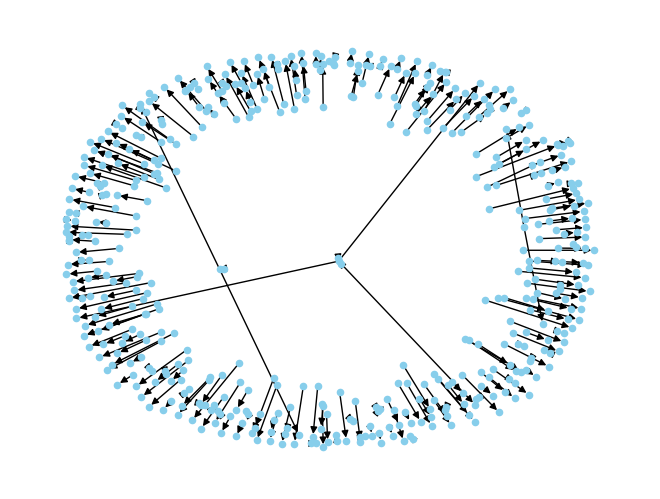

In [10]:
nx.draw(graph, with_labels=False, node_size=20, node_color="skyblue", pos=nx.spring_layout(graph))
plt.show()

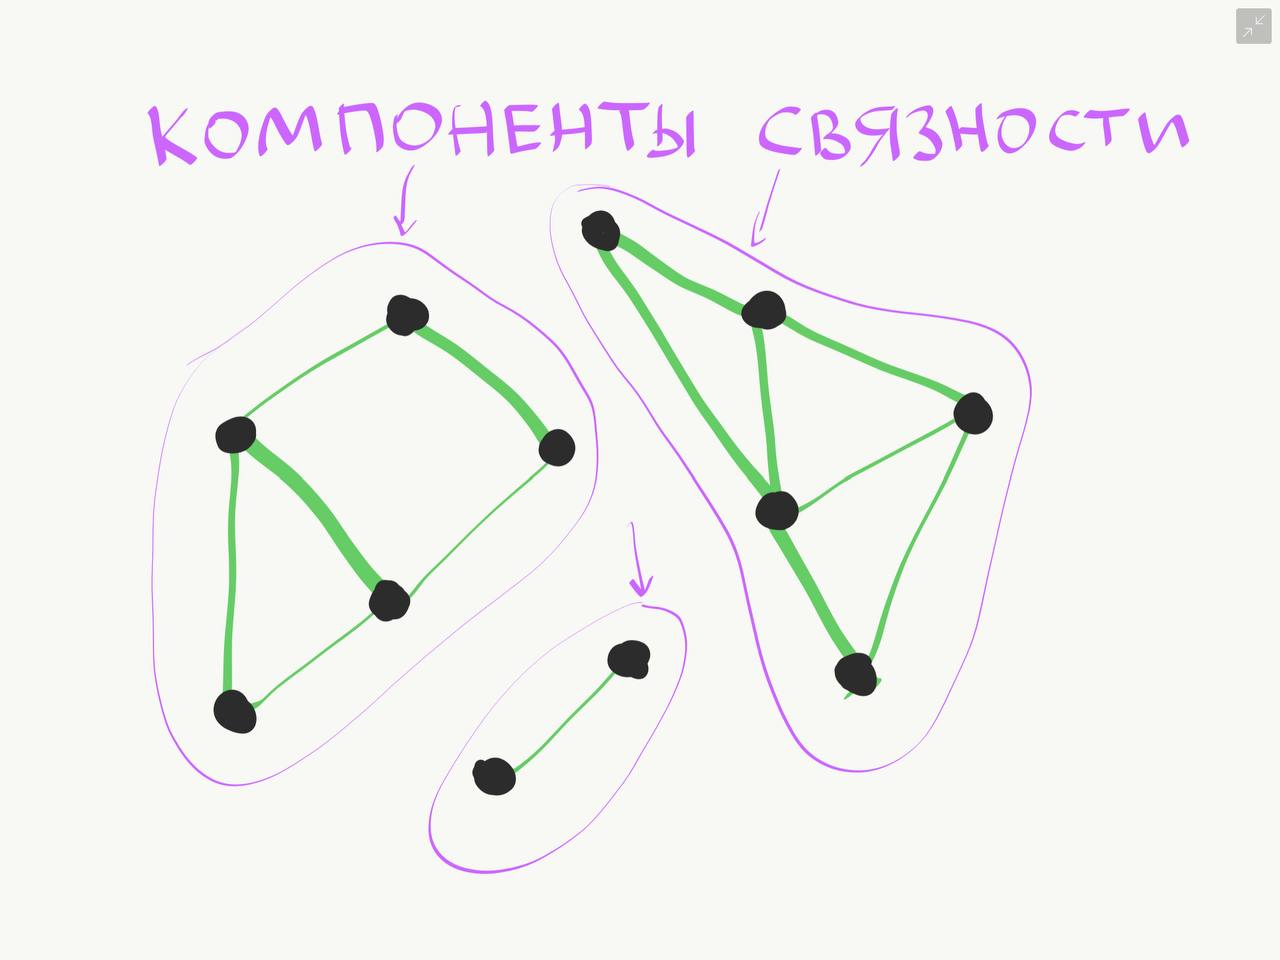

Для направленных графов различают:
- Слабо связные компоненты - игнорируют направление ребер.
- Сильно связные компоненты - учитывают направление, путь должен существовать в обе стороны.

In [11]:
weakly_connected_components = list(nx.weakly_connected_components(graph))
weakly_connected_components_sorted = sorted(weakly_connected_components, key=len, reverse=True)

print("Слабо связные компоненты, отсортированные по размеру:")
for i, component in enumerate(weakly_connected_components_sorted):
    if(len(component) > 2):
        print(f"  Компонента {i+1} (размер {len(component)}): {component}")

Слабо связные компоненты, отсортированные по размеру:
  Компонента 1 (размер 6): {'Миронов Пётр Александрович', 'Елисеева Сати Вячеславовна', 'Дорофеева Гулия Николаевна', 'Шубин Всеволод Валерьевич', 'Галкина Елена Тарасовна', 'Пахомов Анатолий Васильевич'}
  Компонента 2 (размер 4): {'Королева Радмила Олеговна', 'Цветков Валерий Ростиславович', 'Котова Виктория Архиповна', 'Петухова Медина Максимовна'}
  Компонента 3 (размер 4): {'Сенчукова Екатерина Семеновна', 'Коробов Вадим Александрович', 'Рогачев Антон Владимирович', 'Мухамадеев Александр Валерьевич'}
  Компонента 4 (размер 4): {'Федотов Ростислав Богуславович', 'Суворов Илья Макарович', 'Мамонтов Мстислав Георгиевич', 'Архипова Анна Игоревна'}
  Компонента 5 (размер 3): {'Воробьев Иван Александрович', 'Комин Сергей Николаевич', 'Павлова Мария Геннадиевна'}
  Компонента 6 (размер 3): {'Александрова Лариса Евгеньевна', 'Силина Радмила Викторовна', 'Стрелков Евгений Егорович'}


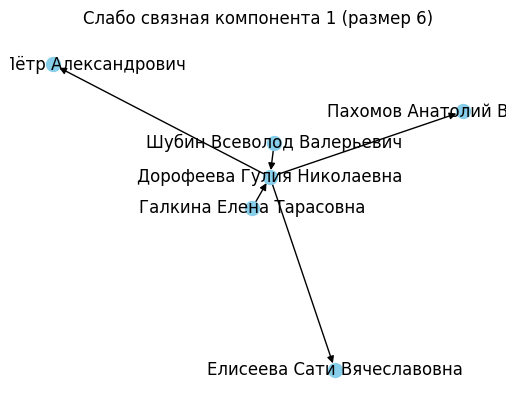

In [20]:
for i, component in enumerate(weakly_connected_components_sorted[:1]):
    subgraph = graph.subgraph(component) # Подграф из вершин компоненты
    plt.title(f"Слабо связная компонента {i+1} (размер {len(component)})")

    nx.draw(subgraph, with_labels=True, node_size=100, node_color="skyblue", pos=nx.spring_layout(subgraph))
    plt.show()

По данной картинке уже можем сказать, что клиент Дорофеева является неблагонадежным клиентом: имеет большое количество аварий, в которых является как виновной, так и потерпевшей. Скорее всего, для страховой компании может быть выгодно отказаться от такого клиента.

In [12]:
strongly_connected_components = list(nx.strongly_connected_components(graph))
strongly_connected_components_sorted = sorted(strongly_connected_components, key=len, reverse=True)

print("Сильно связные компоненты, отсортированные по размеру:")
for i, component in enumerate(strongly_connected_components_sorted):
    if len(component) > 1:
        print(f"  Компонента {i+1} (размер {len(component)}): {component}")

Сильно связные компоненты, отсортированные по размеру:
  Компонента 1 (размер 3): {'Воробьев Иван Александрович', 'Комин Сергей Николаевич', 'Павлова Мария Геннадиевна'}


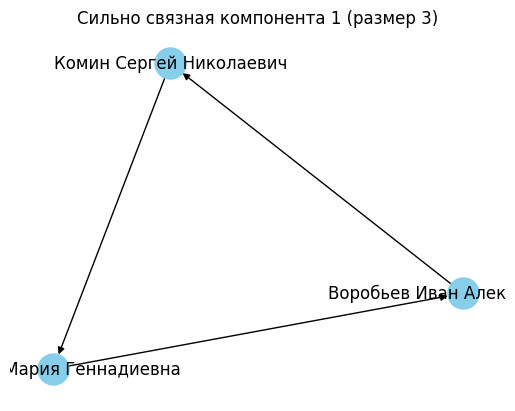

In [19]:
for i, component in enumerate(strongly_connected_components_sorted[:1]):
    subgraph = graph.subgraph(component) # Подграф из вершин компоненты
    plt.title(f"Сильно связная компонента {i+1} (размер {len(component)})")

    nx.draw(subgraph, with_labels=True, node_size=500, node_color="skyblue", pos=nx.spring_layout(subgraph))
    plt.show()

Здесь мы обнаружили потенциальную мошенническую группу. Данные люди могли часто менять авто и делать "подставные" ДТП.

**Степень вершины** - количество рёбер, инцидентных указанной вершине. По-другому - количество рёбер, исходящих из вершины.

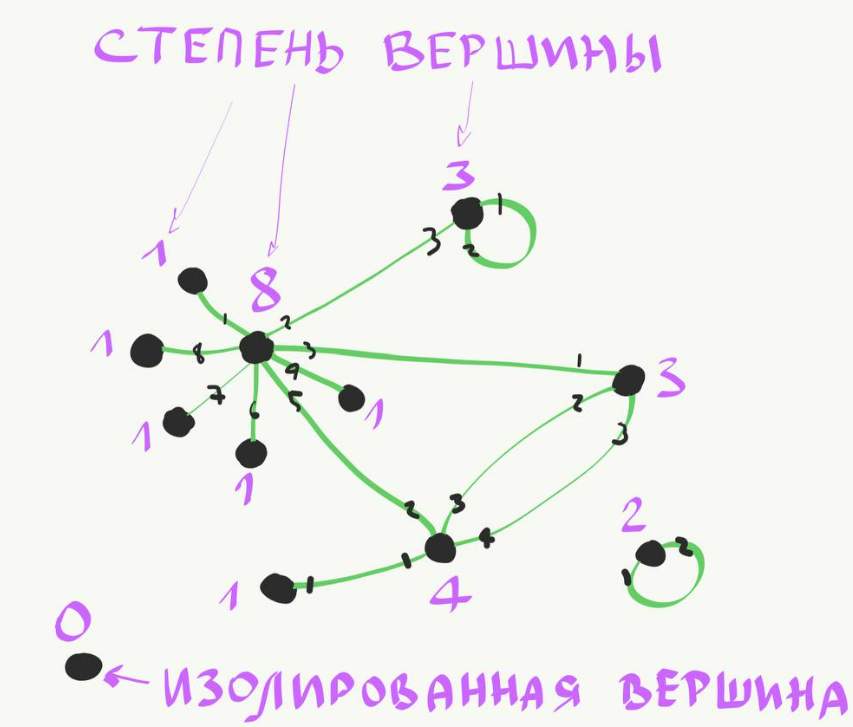

Входящая и исходящая степень:
- Входящая степень (полустепень входа вершины) - количество ребер, входящих в вершину.
- Исходящая степень (полустепень исхода вершины) - количество ребер, исходящих из вершины.

Отсортировав по степени, мы найдем в случае входящей степени людей, которые много раз были потерпевшими, в случае исходящей - виновными. Таких людей, скорее всего, стоит проанализировать более детально отдельно.

In [21]:
in_degrees = dict(graph.in_degree())
sorted_in_degrees = sorted(in_degrees.items(), key=lambda item: item[1], reverse=True)

print("Вершины, отсортированные по входящей степени:")
for node, degree in sorted_in_degrees:
    if degree > 1:
        print(f"  Вершина: {node}, Входящая степень: {degree}")

Вершины, отсортированные по входящей степени:
  Вершина: Дорофеева Гулия Николаевна, Входящая степень: 2
  Вершина: Сенчукова Екатерина Семеновна, Входящая степень: 2
  Вершина: Мамонтов Мстислав Георгиевич, Входящая степень: 2


In [22]:
out_degrees = dict(graph.out_degree())
sorted_out_degrees = sorted(out_degrees.items(), key=lambda item: item[1], reverse=True)

print("Вершины, отсортированные по исходящей степени:")
for node, degree in sorted_out_degrees:
    if degree > 1:
        print(f"  Вершина: {node}, Исходящая степень: {degree}")

Вершины, отсортированные по исходящей степени:
  Вершина: Дорофеева Гулия Николаевна, Исходящая степень: 3
  Вершина: Котова Виктория Архиповна, Исходящая степень: 2
  Вершина: Мухамадеев Александр Валерьевич, Исходящая степень: 2
  Вершина: Стрелков Евгений Егорович, Исходящая степень: 2
